In [1513]:
import numpy as np
from filterpy.kalman import UnscentedKalmanFilter
from filterpy.kalman import MerweScaledSigmaPoints
import jax
import joblib
from matplotlib import pyplot as plt

In [1514]:
light_cureve_dict = joblib.load("Kalman_5_stars.joblib")

#vals is flux
#time (day), flux, possible error recorded by error
print(light_cureve_dict.keys())
t, vals, err = light_cureve_dict[11446443].values()

#set nan_values to be the average of its neighbors
nan_indices = np.argwhere(np.isnan(vals))
for nan_index in nan_indices:
    vals[nan_index] = (vals[nan_index - 1] + vals[nan_index + 1]) / 2

dict_keys([11446443, 11414511, 9579641, 10583181, 8299955])


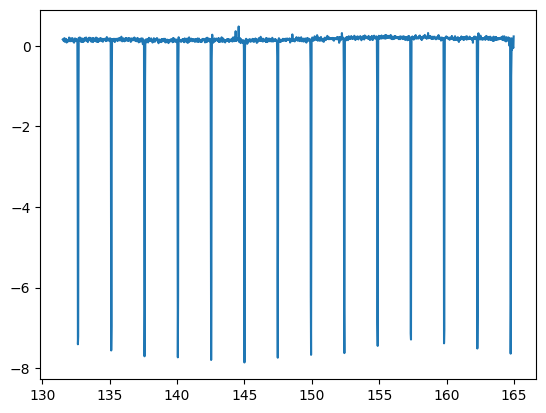

In [1515]:
def normalize_flux(z):
    return (z - np.mean(z)) / np.std(z)

z = vals
z_norm = normalize_flux(z)
plt.plot(t, z_norm)

In [1516]:
d = 8.0 # depth of the transit
phi0=0.0 # when in the cycle we are saying a transit occurs
s = 0.08 # how long the transit lasts
dt = 0.01 # time step

#remove the transit dips and then average out the 
q1, q2, q3 = np.quantile(z_norm, [0.25, 0.5, 0.75])
IQR = q3 - q1
lower_bound = q1 - 2 * IQR
B = np.median(z_norm[z_norm >= lower_bound])

## Attempt 1

#### Update the state space model:

we will have $x=[\phi, \dot{\phi}]$ where 
- $\phi$: the phase of the planet
- $\dot{\phi}$: is the angular velocity of the planet

We will model the state and velocity as standard physics model ie 
$$
    \begin{align*}
        \phi_{k+1} &= \phi_k + \Delta t \dot{\phi_k} + w_{1_k} \\
        \dot{\phi}_{k+1} &= \dot{\phi_k} + w_{2_k}
    \end{align*}
$$

where $w_{1_k} \sim N(0, \sigma_{w_1}^2)$ and $w_{2_k} \sim N(0, \sigma_{w_2}^2)$

thus we can write our full model as $x_{k+1} = Fx_k + w_k$ and $w_k \sim N(0, Q)$ and

$$
    \begin{align*}

        F &= \left[
        \begin{matrix}
            1 & \Delta t\\
            0 & 1
        \end{matrix} \\
        \right]\\

        Q &= \left[
        \begin{matrix}
            \sigma_{w_1}^2 & 0\\
            0 & \sigma_{w_2}^2
        \end{matrix}
        \right]
    \end{align*}
$$


We will then have an observation function

$$
    \begin{align*}
        h(\phi) &= B - d\exp \left({\frac{-1 + \cos{(\phi - \phi_0)}}{s}}\right)
    \end{align*}
$$
which defines a dip function in terms of the phase which is the transit and the b is the general trend from the star

We will then run an extended Kalman filter to estimate the state $x$ from the flux observatoins we get from our light curves taken from the Kepler Dataset

We will also normalize our data via $\tilde{z_k} = \frac{z_k - mean(z)}{std(z)}$


In [1517]:
class TransitModel:
    def __init__(self, dt, d, phi0, s, B=0.0):
        self.dt = dt

        # transit parameters
        self.d = d
        self.phi0 = phi0
        self.s = s
        self.B = B

    def wrap_phase(self, phi):
        return (phi + np.pi) % (2 * np.pi) - np.pi

    #state transition function
    def fx(self, x, dt=None):
        if dt is None:
            dt = self.dt

        phi, phi_dot = x

        phi_new = phi + dt * phi_dot
        phi_dot_new = phi_dot

        phi_new = self.wrap_phase(phi_new)

        return np.array([phi_new, phi_dot_new])

    #observation function
    def hx(self, x):
        phi, _ = x

        return np.array([
            self.B - self.d * np.exp((1-np.cos(phi - self.phi0)) / (self.s))
        ])


    #Jacobian Functions
    def F_jacobian(self, x):
        return np.array([
            [1, self.dt],
            [0, 1]
        ])

    def H_jacobian(self, x):
        phi, _ = x

        exp_term = np.exp((-1 + np.cos(phi - self.phi0)) / self.s)

        dh_dphi = (
            (self.d / self.s)
            * exp_term
            * np.sin(phi - self.phi0)
        )

        return np.array([[dh_dphi, 0.0]])

In [1518]:
model = TransitModel(dt, d=d, phi0=phi0, s=s, B=B)

In [1519]:
points = MerweScaledSigmaPoints(n=2, alpha=0.1, beta=2.0, kappa=0)
ukf = UnscentedKalmanFilter(
    dim_x=2,
    dim_z=1,
    dt=dt,
    fx=model.fx,
    hx=model.hx,
    points=points
)

ukf.x = np.array([np.pi, 2*np.pi/10])
ukf.P = np.diag([1e-3, 1e-2])

q = 1e-4
ukf.Q = np.diag([q, q])
ukf.R = np.array([[0.05]])

xs = []
Ps = []

for z in z_norm:
    ukf.predict()
    ukf.x[0] = model.wrap_phase(ukf.x[0])

    ukf.update(z)
    ukf.x[0] = model.wrap_phase(ukf.x[0])

    xs.append(ukf.x.copy())
    Ps.append(ukf.P.copy())

xs = np.array(xs)

z_pred = np.array([model.hx(x)[0] for x in xs])

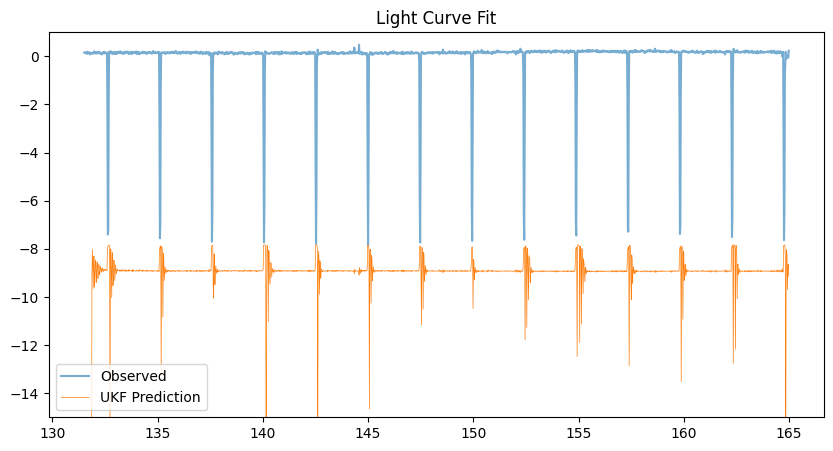

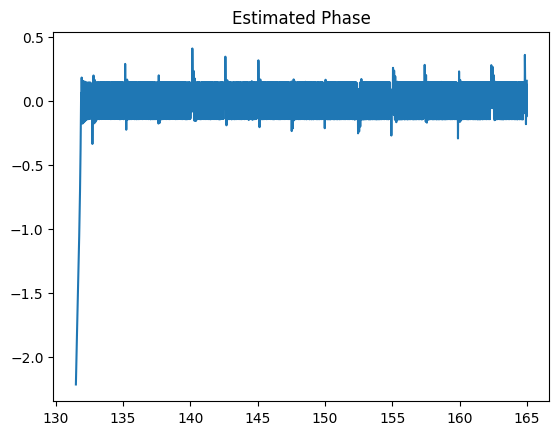

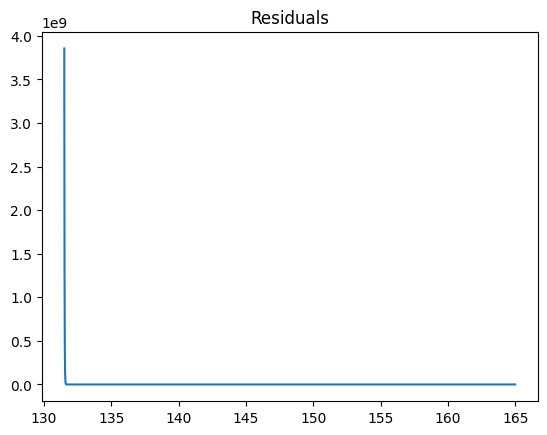

In [1520]:
#Plotting
plt.figure(figsize=(10,5))
plt.plot(t, z_norm, label="Observed", alpha=0.6)
plt.plot(t, z_pred, label="UKF Prediction", linewidth=0.5)
plt.ylim(-15, 1)
plt.legend()
plt.title("Light Curve Fit")
plt.show()

phi_est = xs[:, 0]
plt.figure()
plt.plot(t, phi_est)
plt.title("Estimated Phase")
plt.show()

residuals = z_norm - z_pred
plt.figure()
plt.plot(t, residuals)
plt.title("Residuals")
plt.show()

## Attempt 2 (sin and cos of phase instead of just the phase)

In [1521]:
class TransitModelTrig:
    def __init__(self, dt, d, phi0, s_param, B=0.0):
        self.dt = dt

        # transit parameters
        self.d = d
        self.phi0 = phi0
        self.s_param = s_param
        self.B = B

    # -----------------------
    # State transition
    # -----------------------
    def fx(self, x, dt=None):
        if dt is None:
            dt = self.dt

        c, s, omega = x

        theta = omega * dt
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)

        c_new = c * cos_t - s * sin_t
        s_new = s * cos_t + c * sin_t

        omega_new = omega

        return np.array([c_new, s_new, omega_new])

    # -----------------------
    # Observation function
    # -----------------------
    def hx(self, x):
        c, s, _ = x

        # recover cos(phi - phi0)
        cos_phi0 = np.cos(self.phi0)
        sin_phi0 = np.sin(self.phi0)

        cos_shift = c * cos_phi0 + s * sin_phi0

        return np.array([
            self.B - self.d * np.exp((-1 + cos_shift) / self.s_param)
        ])

In [1522]:
model = TransitModelTrig(dt, d, phi0, s, B)

In [1523]:
points = MerweScaledSigmaPoints(n=3, alpha=0.1, beta=2.0, kappa=0)

ukf = UnscentedKalmanFilter(
    dim_x=3,
    dim_z=1,
    dt=dt,
    fx=model.fx,
    hx=model.hx,
    points=points
)

# initial state
phi_init = 0.0
omega_init = 2 * np.pi / 5

ukf.x = np.array([
    np.cos(phi_init),
    np.sin(phi_init),
    omega_init
])

ukf.P = np.diag([1e-3, 1e-3, 1e-2])

# process noise
q = 1e-4
ukf.Q = np.diag([q, q, q])

# measurement noise
ukf.R = np.array([[0.1]])

In [1524]:
xs = []

for z in z_norm:
    ukf.predict()
    ukf.update(z)

    xs.append(ukf.x.copy())

xs = np.array(xs)
phi_est = np.arctan2(xs[:,1], xs[:,0])
z_pred = np.array([model.hx(x) for x in xs])

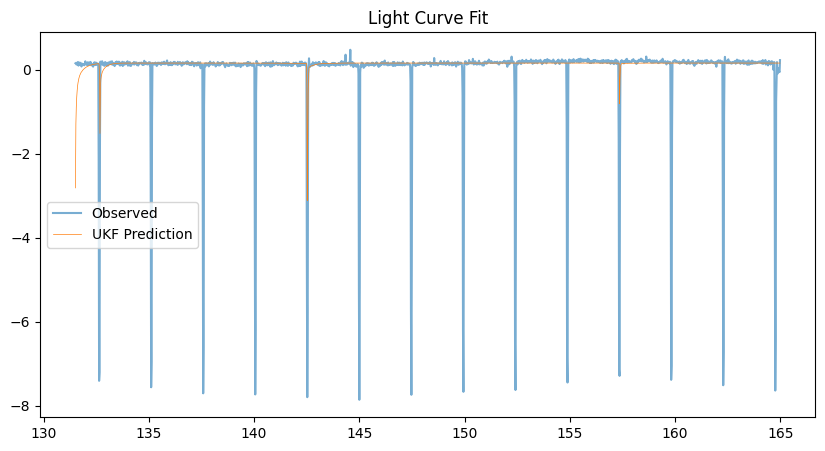

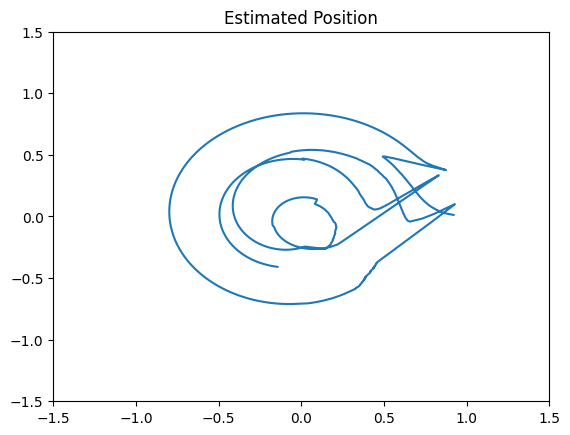

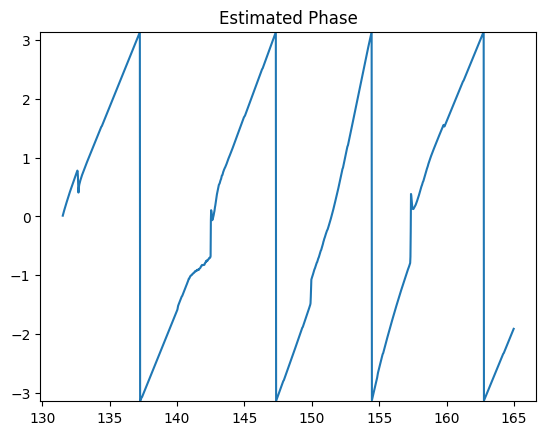

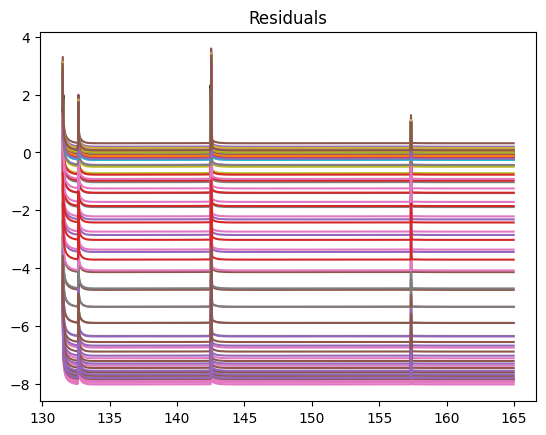

In [1525]:
#Plotting
plt.figure(figsize=(10,5))
plt.plot(t, z_norm, label="Observed", alpha=0.6)
plt.plot(t, z_pred, label="UKF Prediction", linewidth=0.5)
# plt.ylim(-8, 1)
plt.legend()
plt.title("Light Curve Fit")
plt.show()

plt.figure()
plt.plot(xs[:, 0], xs[:, 1])
plt.ylim(-1.5, 1.5)
plt.xlim(-1.5, 1.5)
plt.title("Estimated Position")
plt.show()

plt.figure()
plt.plot(t, phi_est)
plt.ylim(-np.pi, np.pi)
plt.title("Estimated Phase")
plt.show()

residuals = z_norm - z_pred
plt.figure()
plt.plot(t, residuals)
plt.title("Residuals")
plt.show()

## Attempt 3

In [1526]:
class TransitModelPhase:
    def __init__(self, dt, d, phi0, s_param, B=0.0):
        self.dt = dt

        # transit parameters
        self.d = d
        self.phi0 = phi0
        self.s_param = s_param
        self.B = B

    # -----------------------
    # State transition
    # -----------------------
    def fx(self, x, dt=None):
        if dt is None:
            dt = self.dt

        phi, phi_dot = x

        phi_new = phi + dt * phi_dot
        phi_dot_new = phi_dot

        return np.array([phi_new, phi_dot_new])

    # -----------------------
    # Observation function
    # -----------------------
    def hx(self, x):
        phi, _ = x

        cos_shift = np.cos(phi - self.phi0)

        return np.array([
            self.B - self.d * np.exp((-1 + cos_shift) / self.s_param)
        ])
    
    

In [1527]:
model = TransitModelPhase(dt, d, phi0, s, B)

points = MerweScaledSigmaPoints(n=2, alpha=0.1, beta=2.0, kappa=0)

ukf = UnscentedKalmanFilter(
    dim_x=2,
    dim_z=1,
    dt=dt,
    fx=model.fx,
    hx=model.hx,
    points=points
)

# initial state
phi_init = 0.0
omega_init = 2 * np.pi / 5

ukf.x = np.array([phi_init, omega_init])

ukf.P = np.diag([1e-3, 1e-3])

# process noise
q_phi = 5e-3
q_omega = 1e-4
ukf.Q = np.diag([q_phi, q_omega])

# measurement noise
ukf.R = np.array([[0.1]])

In [1528]:
xs = []

for z in z_norm:
    ukf.predict()
    ukf.update(z)

    xs.append(ukf.x.copy())

xs = np.array(xs)

phi_est = xs[:, 0]
z_pred = np.array([model.hx(x) for x in xs])

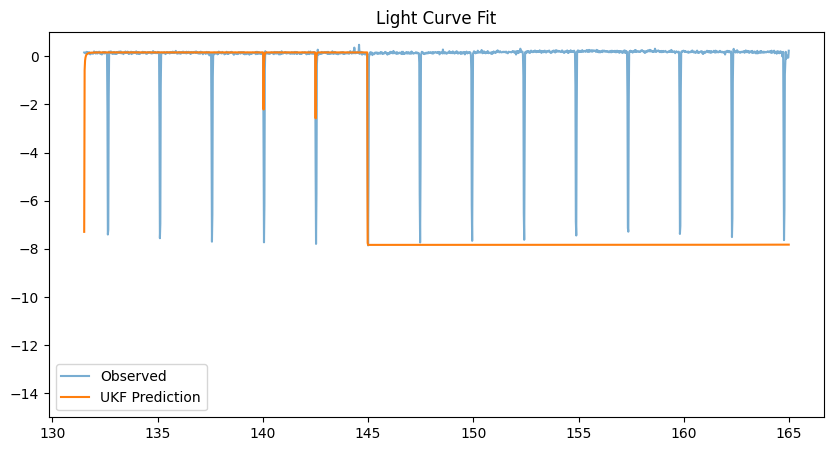

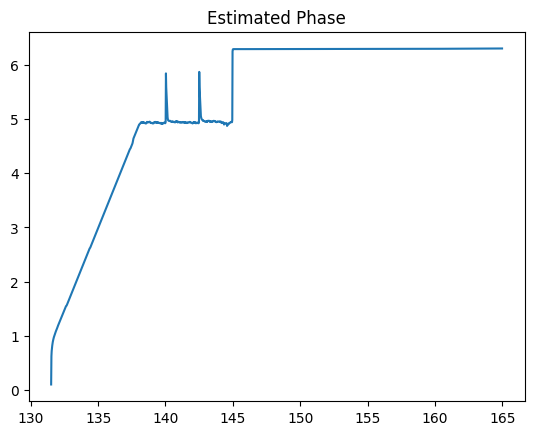

In [1529]:
#Plotting
plt.figure(figsize=(10,5))
plt.plot(t, z_norm, label="Observed", alpha=0.6)
plt.plot(t, z_pred, label="UKF Prediction")
plt.ylim(-15, 1)
plt.legend()
plt.title("Light Curve Fit")
plt.show()

phi_est = xs[:, 0]
plt.figure()
plt.plot(t, phi_est)
plt.title("Estimated Phase")
plt.show()